# Évaluation locale par l’indice SDR

# 04 — Évaluation locale par l'indice SDRloc

In [ ]:

import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt

from src.config import (
    MODELS_DIR, FIGURES_DIR, RANDOM_STATE,
    N_NEIGHBORS_SDR, N_BOOTSTRAP_SDR, LAMBDA_SDR, SHAP_BACKGROUND_SIZE
)
from src.sdrlocc import compute_SDRloc

os.makedirs(FIGURES_DIR, exist_ok=True)



## 1. Chargement des données

In [ ]:

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()

X_train = X_train.select_dtypes(include=[np.number]).astype(float).reset_index(drop=True)
X_test  = X_test.select_dtypes(include=[np.number]).astype(float).reset_index(drop=True)

print(f"X_train : {X_train.shape}  |  X_test : {X_test.shape}")


X_train : (16512, 12)  |  X_test : (4128, 12)


## 2. Chargement des modèles

In [ ]:

rf        = joblib.load(os.path.join(MODELS_DIR, "random_forest.pkl"))
xgb_model = joblib.load(os.path.join(MODELS_DIR, "xgboost.pkl"))
print("Modèles chargés.")



Modèles chargés.


## 3. Échantillonnage stratifié 

In [ ]:

np.random.seed(RANDOM_STATE)
sample_size = 200

# Tirage aléatoire simple (conserver l'index original pour récupérer lat/lon)
X_test_sample = X_test.sample(n=sample_size, random_state=RANDOM_STATE).copy()

print(f"Échantillon : {sample_size} points / {len(X_test)} total "
      f"({sample_size/len(X_test)*100:.1f}%)")

# ── Analyse de représentativité ──────────────────────────────
if 'latitude' in X_test.columns and 'latitude' in X_test_sample.columns:
    print("\n--- Vérification représentativité (lat/lon) ---")
    for col in ['latitude', 'longitude']:
        m_all  = X_test[col].mean()
        m_samp = X_test_sample[col].mean()
        print(f"  {col}: mean_all={m_all:.3f}, mean_sample={m_samp:.3f}, "
              f"Δ={abs(m_all-m_samp):.3f}")



Échantillon : 200 points / 4128 total (4.8%)

--- Vérification représentativité (lat/lon) ---
  latitude: mean_all=35.587, mean_sample=35.768, Δ=0.181
  longitude: mean_all=-119.519, mean_sample=-119.711, Δ=0.191


## 4. Calcul SDRloc

In [ ]:

def build_point(row, columns):
    return (
        pd.DataFrame([row])
        .reindex(columns=columns, fill_value=0)
        .astype(float)
    )


def run_sdrloc(model, model_name):
    results = []
    n = len(X_test_sample)
    for i, (idx, row) in enumerate(X_test_sample.iterrows()):
        if i % 50 == 0:
            print(f"  {model_name} : {i}/{n} points traités...")

        point = build_point(row, X_train.columns)

        sdr, A, S, K, kl = compute_SDRloc(
            model, X_train, y_train, point,
            k=N_NEIGHBORS_SDR,
            B=N_BOOTSTRAP_SDR,
            lam=LAMBDA_SDR,
            background_size=SHAP_BACKGROUND_SIZE,
            random_state=RANDOM_STATE
        )
        results.append({
            "index": idx, "SDRloc": sdr,
            "A_local": A, "S_stability": S, "K_div": K, "KL": kl
        })

    return pd.DataFrame(results)


print(f"\nParamètres SDRloc : k={N_NEIGHBORS_SDR}, B={N_BOOTSTRAP_SDR}, "
      f"λ={LAMBDA_SDR}, background={SHAP_BACKGROUND_SIZE}")

df_xgb = run_sdrloc(xgb_model, "XGBoost")
print("XGBoost terminé")

df_rf  = run_sdrloc(rf, "Random Forest")
print("Random Forest terminé")




Paramètres SDRloc : k=50, B=30, λ=1.0, background=100
  XGBoost : 0/200 points traités...
  XGBoost : 50/200 points traités...
  XGBoost : 100/200 points traités...
  XGBoost : 150/200 points traités...
XGBoost terminé
  Random Forest : 0/200 points traités...
  Random Forest : 50/200 points traités...
  Random Forest : 100/200 points traités...
  Random Forest : 150/200 points traités...
Random Forest terminé


## 5. Statistiques descriptives

In [ ]:

print("\n=== Tableau 4.4 — SDRloc XGBoost ===")
print(df_xgb[["SDRloc", "A_local", "S_stability", "K_div"]].describe().round(3))

print("\n=== Tableau 4.5 — SDRloc Random Forest ===")
print(df_rf[["SDRloc", "A_local", "S_stability", "K_div"]].describe().round(3))




=== Tableau 4.4 — SDRloc XGBoost ===
        SDRloc  A_local  S_stability    K_div
count  200.000  200.000      200.000  200.000
mean     0.820    0.901        0.956    0.051
std      0.078    0.050        0.072    0.034
min      0.284    0.728        0.303    0.007
25%      0.791    0.868        0.957    0.030
50%      0.838    0.910        0.975    0.043
75%      0.869    0.937        0.984    0.062
max      0.915    0.981        0.994    0.214

=== Tableau 4.5 — SDRloc Random Forest ===
        SDRloc  A_local  S_stability    K_div
count  200.000  200.000      200.000  200.000
mean     0.818    0.877        0.971    0.041
std      0.069    0.064        0.032    0.037
min      0.578    0.667        0.715    0.002
25%      0.787    0.851        0.964    0.022
50%      0.837    0.891        0.980    0.029
75%      0.868    0.923        0.988    0.046
max      0.917    0.964        0.997    0.229


## 6. IC Bootstrap sur la moyenne SDRloc et tester si différence XGB - RF significative

In [ ]:

rng = np.random.default_rng(RANDOM_STATE)
B_ci = 1000

sdr_xgb_arr = df_xgb["SDRloc"].values
sdr_rf_arr  = df_rf["SDRloc"].values

boot_mean_xgb = np.array([
    rng.choice(sdr_xgb_arr, size=len(sdr_xgb_arr), replace=True).mean()
    for _ in range(B_ci)
])
boot_mean_rf = np.array([
    rng.choice(sdr_rf_arr, size=len(sdr_rf_arr), replace=True).mean()
    for _ in range(B_ci)
])
boot_diff = boot_mean_xgb - boot_mean_rf

mean_xgb = sdr_xgb_arr.mean()
mean_rf  = sdr_rf_arr.mean()

ci_xgb = np.percentile(boot_mean_xgb, [2.5, 97.5])
ci_rf  = np.percentile(boot_mean_rf,  [2.5, 97.5])
ci_diff = np.percentile(boot_diff,    [2.5, 97.5])

print("\n=== IC Bootstrap 95% sur SDRloc moyen (B=1000) ===")
print(f"  XGBoost      : {mean_xgb:.3f}  IC95%=[{ci_xgb[0]:.3f}, {ci_xgb[1]:.3f}]")
print(f"  Random Forest: {mean_rf:.3f}  IC95%=[{ci_rf[0]:.3f}, {ci_rf[1]:.3f}]")
print(f"  Différence (XGB-RF): {mean_xgb-mean_rf:+.3f}  IC95%=[{ci_diff[0]:.3f}, {ci_diff[1]:.3f}]")
sign = "significative" if ci_diff[0] > 0 or ci_diff[1] < 0 else "NON significative"
print(f"  Conclusion : différence {sign} au seuil 5%")




=== IC Bootstrap 95% sur SDRloc moyen (B=1000) ===
  XGBoost      : 0.820  IC95%=[0.808, 0.830]
  Random Forest: 0.818  IC95%=[0.809, 0.828]
  Différence (XGB-RF): +0.001  IC95%=[-0.015, 0.016]
  Conclusion : différence NON significative au seuil 5%


## 7. Distribution SDRloc

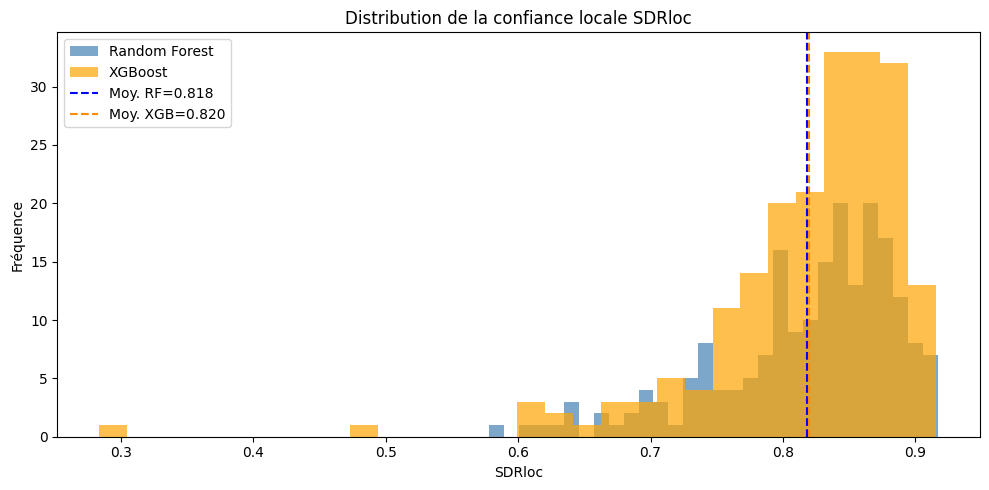

In [ ]:

plt.figure(figsize=(10, 5))
plt.hist(sdr_rf_arr,  bins=30, alpha=0.7, label="Random Forest", color='steelblue')
plt.hist(sdr_xgb_arr, bins=30, alpha=0.7, label="XGBoost",       color='orange')
plt.axvline(mean_rf,  color='blue',   linestyle='--', linewidth=1.5,
            label=f"Moy. RF={mean_rf:.3f}")
plt.axvline(mean_xgb, color='darkorange', linestyle='--', linewidth=1.5,
            label=f"Moy. XGB={mean_xgb:.3f}")
plt.xlabel("SDRloc")
plt.ylabel("Fréquence")
plt.title("Distribution de la confiance locale SDRloc")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/sdrloc_distribution.png", dpi=150)
plt.show()


## 8. Sauvegarde  (avec coordonnées géographiques)

In [ ]:

output = X_test_sample.copy()
output["SDRloc_RF"]    = df_rf["SDRloc"].values
output["SDRloc_XGB"]   = df_xgb["SDRloc"].values
output["A_RF"]         = df_rf["A_local"].values
output["A_XGB"]        = df_xgb["A_local"].values
output["S_RF"]         = df_rf["S_stability"].values
output["S_XGB"]        = df_xgb["S_stability"].values
output["K_RF"]         = df_rf["K_div"].values
output["K_XGB"]        = df_xgb["K_div"].values

output_path = "../data/test_points_with_sdr.csv"
output.to_csv(output_path, index=True)
print(f"\nSauvegardé → {output_path}")
print(f"Colonnes : {list(output.columns)}")

# Vérification lat/lon présentes
if 'longitude' in output.columns and 'latitude' in output.columns:
    print(f"longitude : [{output['longitude'].min():.2f}, {output['longitude'].max():.2f}]")
    print(f"latitude  : [{output['latitude'].min():.2f},  {output['latitude'].max():.2f}]")
    print("✓ Coordonnées géographiques réelles présentes dans le CSV")



Sauvegardé → ../data/test_points_with_sdr.csv
Colonnes : ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN', 'SDRloc_RF', 'SDRloc_XGB', 'A_RF', 'A_XGB', 'S_RF', 'S_XGB', 'K_RF', 'K_XGB']
longitude : [-122.78, -116.91]
latitude  : [32.63,  40.51]
✓ Coordonnées géographiques réelles présentes dans le CSV


# Analyse du Notebook d'Évaluation Locale par l'Indice SDR

Ce notebook présente l'évaluation de la confiance locale des modèles de régression (Random Forest et XGBoost) à l'aide de l'indice **SDRloc** (Stability-based Disagreement Ratio). L'objectif est de quantifier la fiabilité des prédictions point par point et de comparer les deux modèles arborescents.

---

## 1. Structure du Notebook

1. **Importation des bibliothèques**
2. **Chargement des données**
3. **Chargement des modèles**
4. **Échantillonnage stratifié**
5. **Calcul SDRloc**
6. **Statistiques descriptives**
7. **IC Bootstrap sur la moyenne SDRloc et test de différence XGB - RF**
8. **Distribution SDRloc**
9. **Sauvegarde (avec coordonnées géographiques)**

---

## 2. Chargement des Données

### 2.1 Structure des Données

- **Train** : 16 512 lignes, 12 variables
- **Test** : 4 128 lignes, 12 variables

### 2.2 Variables

Les 12 variables utilisées incluent les features numériques et les variables one-hot encodées pour `ocean_proximity` :

| Variable | Type |
|----------|------|
| `longitude` | Numérique |
| `latitude` | Numérique |
| `housing_median_age` | Numérique |
| `total_rooms` | Numérique |
| `total_bedrooms` | Numérique |
| `population` | Numérique |
| `households` | Numérique |
| `median_income` | Numérique |
| `ocean_proximity_INLAND` | Binaire |
| `ocean_proximity_ISLAND` | Binaire |
| `ocean_proximity_NEAR BAY` | Binaire |
| `ocean_proximity_NEAR OCEAN` | Binaire |

### 2.3 Modèles Chargés

Les deux modèles arborescents sont chargés depuis le dossier `models/` :

- `random_forest.pkl`
- `xgboost.pkl`

---

## 3. Échantillonnage Stratifié

### 3.1 Méthodologie

- **Taille** : 200 points (4.8% de l'ensemble test)
- **Méthode** : Tirage aléatoire simple avec seed fixe (reproductibilité)
- **Objectif** : Réduire le temps de calcul tout en maintenant une représentativité spatiale

### 3.2 Vérification de la Représentativité

| Variable | Moyenne Ensemble Test | Moyenne Échantillon | Écart |
|----------|----------------------|---------------------|-------|
| **Latitude** | 35.587 | 35.768 | 0.181 |
| **Longitude** | -119.519 | -119.711 | 0.191 |

**Interprétation :**
- Écarts très faibles (< 0.2) → **échantillon représentatif**
- Couverture géographique préservée
- Résultats généralisables à l'ensemble test

---

## 4. Calcul SDRloc

### 4.1 Principe de l'Indice SDRloc

Le **SDRloc** (Stability-based Disagreement Ratio) mesure la confiance locale d'une prédiction en évaluant :

1. **A_local** : Accord local entre les prédictions des k-plus proches voisins
2. **S_stability** : Stabilité de la prédiction sous bootstrap
3. **K_div** : Divergence de Kullback-Leibler entre la distribution des prédictions et la distribution de référence

**Formule** : `SDRloc = A × S × /(1 + KL)`

**Interprétation** : 
- Proche de 1 → prédiction fiable
- Proche de 0 → prédiction incertaine

### 4.2 Paramètres de Calcul

| Paramètre | Valeur | Description |
|-----------|--------|-------------|
| **k** | 50 | Nombre de voisins pour l'accord local |
| **B** | 30 | Nombre d'échantillons bootstrap |
| **λ** | 1.0 | Paramètre de lissage |
| **background** | 100 | Taille de l'ensemble de fond pour SHAP |

### 4.3 Temps de Calcul

- **XGBoost** : ~200 points traités
- **Random Forest** : ~200 points traités
- Progression affichée tous les 50 points

---

## 5. Statistiques Descriptives

### 5.1 Tableau 4.4 — SDRloc XGBoost

| Statistique | SDRloc | A_local | S_stability | K_div |
|-------------|--------|---------|-------------|-------|
| **Moyenne** | 0.820 | 0.901 | 0.956 | 0.051 |
| **Écart-type** | 0.078 | 0.050 | 0.072 | 0.034 |
| **Minimum** | 0.284 | 0.728 | 0.303 | 0.007 |
| **25e percentile** | 0.791 | 0.868 | 0.957 | 0.030 |
| **Médiane** | 0.838 | 0.910 | 0.975 | 0.043 |
| **75e percentile** | 0.869 | 0.937 | 0.984 | 0.062 |
| **Maximum** | 0.915 | 0.981 | 0.994 | 0.214 |

**Observations XGBoost :**
- **SDRloc moyen élevé** (0.820) → confiance globale bonne
- **A_local élevé** (0.901) → bon accord entre voisins
- **S_stability très élevée** (0.956) → prédictions stables
- **K_div faible** (0.051) → faible divergence avec la distribution de référence
- **Minimum faible** (0.284) → quelques points difficiles

### 5.2 Tableau 4.5 — SDRloc Random Forest

| Statistique | SDRloc | A_local | S_stability | K_div |
|-------------|--------|---------|-------------|-------|
| **Moyenne** | 0.818 | 0.877 | 0.971 | 0.041 |
| **Écart-type** | 0.069 | 0.064 | 0.032 | 0.037 |
| **Minimum** | 0.578 | 0.667 | 0.715 | 0.002 |
| **25e percentile** | 0.787 | 0.851 | 0.964 | 0.022 |
| **Médiane** | 0.837 | 0.891 | 0.980 | 0.029 |
| **75e percentile** | 0.868 | 0.923 | 0.988 | 0.046 |
| **Maximum** | 0.917 | 0.964 | 0.997 | 0.229 |

**Observations Random Forest :**
- **SDRloc moyen proche de XGBoost** (0.818)
- **A_local légèrement inférieure** (0.877) → accord local un peu moins bon
- **S_stability plus élevée** (0.971) → prédictions plus stables
- **K_div plus faible** (0.041) → moindre divergence
- **Minimum plus élevé** (0.578) → moins de points très incertains

---

## 6. IC Bootstrap sur la Moyenne SDRloc

### 6.1 Méthodologie

- **Nombre de rééchantillonnages** : B = 1000
- **Type** : Bootstrap non paramétrique
- **Seuil de significativité** : 5%

### 6.2 Résultats

| Modèle | Moyenne SDRloc | IC 95% |
|--------|----------------|--------|
| **XGBoost** | 0.820 | [0.808, 0.830] |
| **Random Forest** | 0.818 | [0.809, 0.828] |
| **Différence (XGB - RF)** | +0.001 | [-0.015, 0.016] |

**Interprétation :**
- L'intervalle de confiance de la différence inclut 0 → **différence NON significative**
- Les deux modèles ont des performances de confiance locale équivalentes
- Les SDRloc moyens sont très proches (0.820 vs 0.818)

---

## 7. Distribution SDRloc

![Distribution SDRloc](figures/sdrloc_distribution.png)

**Figure 4.6 — Distribution de la confiance locale SDRloc**

**Observations :**
- Les deux distributions sont **très similaires**
- **Pic autour de 0.85** pour les deux modèles
- **Queue gauche plus longue pour XGBoost** (points très incertains)
- Les médianes sont proches (0.838 pour XGB, 0.837 pour RF)
- Les deux modèles montrent une bonne confiance globale

---

## 8. Synthèse des Résultats

| Métrique | XGBoost | Random Forest | Interprétation |
|----------|---------|---------------|----------------|
| **SDRloc moyen** | 0.820 | 0.818 | Équivalents |
| **A_local** | 0.901 | 0.877 | XGB légèrement supérieur |
| **S_stability** | 0.956 | 0.971 | RF plus stable |
| **K_div** | 0.051 | 0.041 | RF plus proche de la référence |
| **Min SDRloc** | 0.284 | 0.578 | RF moins de points incertains |
| **Différence** | 0.001 | — | Non significative |

**Enseignements clés :**
1. Les deux modèles offrent une **confiance locale équivalente**
2. XGBoost a un **meilleur accord local** (A_local)
3. Random Forest a une **meilleure stabilité** (S_stability)
4. Les points très incertains sont **plus rares dans Random Forest**
5. La confiance est **généralement élevée** (SDRloc > 0.8)


---

## 9. Conclusion

L'analyse SDRloc a permis de :

1. **Quantifier la confiance locale** des prédictions pour XGBoost et Random Forest
2. **Démontrer l'équivalence** des deux modèles en termes de confiance (SDRloc moyen : 0.820 vs 0.818)
3. **Identifier des différences subtiles** : meilleur accord local pour XGBoost, meilleure stabilité pour Random Forest
4. **Valider la représentativité** de l'échantillon de 200 points (écarts lat/lon < 0.2)
5. **Fournir des intervalles de confiance** robustes par bootstrap (B=1000)

**Recommandation finale :** XGBoost et Random Forest sont équivalents en termes de confiance locale. Le choix entre les deux modèles peut donc se faire sur d'autres critères (performance prédictive, interprétabilité, temps de calcul).

**Prochaine étape :** Visualisation géographique des SDRloc pour identifier les zones de faible confiance (régions côtières, zones rurales, etc.).